# Modular RAG 리팩토링

## 실습 목표
---
기존에 구현한 Adaptive RAG 챗봇을 모듈러 시스템으로 리팩토링 하여 여러 컴포넌트를 상황에 따라 자유롭게 이어붙일 수 있는 구조로 개선합니다.

## 실습 목차
---
1. **환경 설정**: 실습에 필요한 라이브러리를 불러오고, 환경 변수, Reranker, 유틸리티 함수 등 RAG 로직을 구현하기 위한 환경을 구성합니다.

2. **Adaptive RAG 리팩토링**: 앞서 구현한 Adaptive RAG의 각 Node와 조건부 간선을 모듈화 합니다.

## 1. 환경 설정
필요한 라이브러리를 불러옵니다.

In [1]:
import contextlib
import io
import os
from typing import List, Optional

import pandas as pd
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

load_dotenv()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_9046/1144030003.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.cross_encoders import HuggingFaceCrossEncoder


True

ChatGPT API(`.env`의 `MODEL_NAME`)로 답변 생성용 `llm`을 만들고, 여기에 JSON 출력을 강제하는 `.bind()`를 적용해 라우팅/평가 전용 `route_llm`을 만듭니다. 임베딩은 01 폴더에서 이미 설치를 안내한 Ollama의 `qwen3-embedding:0.6b`를 그대로 사용합니다.

In [2]:
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
# llm.bind(...)로 JSON 강제 출력 옵션을 추가해 route_llm을 만듭니다. (동일 모델, 다른 출력 형식)
route_llm = llm.bind(response_format={"type": "json_object"})
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

Graph State를 정의합니다.

In [3]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, 라우팅 경로, LLM이 생성한 텍스트, 데이터, 코드를 저장합니다.
    question: str
    route: Optional[str]
    generation: str
    data: str
    code: str

### 1.1 웹 검색 API 초기화

웹 검색을 자동화 하기 위해 Tavily Search API Key를 등록합니다.

1. 먼저, 아래 링크에 접속한 후 'Sign-in' 버튼을 눌러 로그인 화면으로 이동합니다.
   - https://app.tavily.com/sign-in
2. 여러분의 Tavily 계정으로 로그인한 후, 아래 링크에 접속하여 default API Key를 복사합니다.
   - https://app.tavily.com/home
3. 이 노트북과 같은 폴더에 있는 `.env` 파일을 열어 `TAVILY_API_KEY=` 뒤에 복사한 키를 붙여넣고 저장합니다. (01 폴더에서 이미 등록했다면 이 단계는 생략해도 됩니다.)

In [4]:
# API Key는 코드에 직접 입력하지 않고 .env 파일에서 불러옵니다.
# (.env 파일의 TAVILY_API_KEY에 키를 넣어두면 load_dotenv()가 자동으로 환경 변수에 등록합니다.)
assert os.environ.get("TAVILY_API_KEY"), ".env 파일에 TAVILY_API_KEY를 설정해주세요."

In [5]:
excel_data_name = "한국지능정보사회진흥원_인공지능 학습용 데이터 구축 현황_20210104.csv"
pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"

# 데이터를 불러오고, 이름과 컬럼명을 저장합니다.
data_dir = "./data"
df_ai_train_data_dist = pd.read_csv(
    os.path.join(data_dir, excel_data_name), index_col=None
)

# 데이터를 저장한 변수명을 LLM에 제공하여 이 변수를 활용하는 코드를 작성하게 할 수 있습니다.
df_name = "df_ai_train_data_dist"
df_columns = ", ".join(df_ai_train_data_dist.columns)

### 1.3 Reranking 모듈 초기화

In [6]:
# Reranker를 초기화합니다.
top_n_reranked_docs = 3
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
reranker = CrossEncoderReranker(model=cross_encoder, top_n=top_n_reranked_docs)

# 이미 임베딩된 벡터스토어가 있으면 그대로 불러오고, 없으면 PDF를 새로 읽어 임베딩합니다.
persist_dir = "./vectorstore/chroma"
if os.path.exists(persist_dir):
    vectorstore = Chroma(embedding_function=embeddings, persist_directory=persist_dir)
    print(f"[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: {vectorstore._collection.count()})")
else:
    pdf_loader = PyPDFLoader(os.path.join(data_dir, pdf_data_name))
    pdf_docs = pdf_loader.load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
    splited_pdf_docs = text_splitter.split_documents(pdf_docs)
    vectorstore = Chroma.from_documents(
        documents=splited_pdf_docs, embedding=embeddings, persist_directory=persist_dir,
    )
    print(f"[vectorstore] 새로 임베딩 완료 (저장된 벡터 수: {vectorstore._collection.count()})")

# Reranker를 통해 한번 더 정렬할 예정이므로, 탐색할 k값을 top_n의 5배로 설정합니다.
db_retriever = vectorstore.as_retriever(search_kwargs={"k": top_n_reranked_docs * 5})

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: 18)


In [7]:
# LLM이 생성한 코드를 파싱하는 함수를 정의합니다.
def python_code_parser(input: str) -> str:
    # LLM은 대부분 ``` 블럭 안에 코드를 출력합니다. 이를 활용합니다.
    # ```python (코드) ```, 혹은 ``` (코드) ``` 형태로 출력됩니다. 두 경우 모두에 대응하도록 코드를 작성합니다.
    processed_input = input.replace("```python", "```").strip()
    parsed_input_list = processed_input.split("```")

    # 만약 ``` 블럭이 없다면, 입력 텍스트 전체가 코드라고 간주합니다.
    # 아닐 경우 이어지는 코드 실행 과정에서 예외 처리를 통해 오류를 확인할 수 있습니다.
    if len(parsed_input_list) == 1:
        return processed_input

    # 코드 부분만 추출합니다.
    # LLM은 여러 코드 블럭에 걸쳐 필요한 코드를 출력할 수 있으므로, 코드가 있는 홀수 번째 텍스트를 모두 저장합니다.
    parsed_code_list = []
    for i in range(1, len(parsed_input_list), 2):
        parsed_code_list.append(parsed_input_list[i])

    # 코드 부분을 하나로 합칩니다.
    return "\n".join(parsed_code_list)


# 생성한 코드를 실행하는 함수를 정의합니다.
def run_code(input_code: str):
    output = io.StringIO()
    try:
        with contextlib.redirect_stdout(output):
            # 코드가 실행하면서 출력한 모든 결과를 캡쳐합니다.
            exec(input_code, {"df_ai_train_data_dist": df_ai_train_data_dist})
    except Exception as e:
        # 에러가 발생할 경우, 이를 StringIO 객체에 저장합니다.
        print(f"Error: {e}", file=output)
    # StringIO 객체에 저장된 값을 반환합니다.
    return output.getvalue()

## 2. Adaptive RAG 리팩토링
---
앞서 구현한 Adaptive RAG 챗봇의 기능은 유지한 채, 각 기능을 모듈화 하여 유지보수가 용이하도록 리팩토링 합니다.

### 2.1. Node에 대응하는 모듈 구성

단일 기능을 나타내는 Node 단위로 모듈을 구성합니다.

In [8]:
# LangGraph 기반 RAG 시스템을 구성하기 위해, 각 모듈이 상속해야 할 Base 메서드를 정의합니다.
class BaseRAGModule:
    # 각 모듈은 LangGraph Workflow의 노드 역할을 합니다.
    node_id: str

    # 각 모듈은 다음 노드로 전달할 데이터를 반환하는 `run` 메서드를 가져야 합니다.
    def run(self, state: State) -> State:
        raise NotImplementedError

    def __call__(self, state: State) -> State:
        return self.run(state)

챗봇의 각 기능을 모듈로 나누어 구현합니다.

질문이 어떤 경로(문서 RAG / 엑셀 데이터 / 웹 검색 / 일반 답변)로 가야 할지 결정하는 라우팅 모듈을 추가합니다. (기존 코드에는 이 라우팅 모듈이 그래프에 연결되어 있지 않아, PDF 문서 검색 경로가 실제로는 한 번도 실행되지 않는 문제가 있었습니다. 이번 리팩토링에서 4가지 경로가 모두 동작하도록 바로잡습니다.)

In [9]:
class RouterRAGModule(BaseRAGModule):
    node_id = "init_answer"

    def __init__(self, route_llm):
        self.route_llm = route_llm
        system_message = """당신은 사용자의 질문에 RAG, 엑셀 데이터, 웹 검색 중 어떤 것을 활용할지 결정하는 라우팅 전문가입니다.
인공지능 산업 동향(시장 규모, 기업 동향, 정책 등)과 관련된 질문이라면 rag를 선택하세요.
인공지능 학습용 데이터 구축 현황(엑셀 데이터)과 관련된 질문이라면 excel_data를 선택하세요.
둘 다 아니지만 최신 정보나 외부 지식이 필요한 질문이라면 web_search를 선택하세요.
그 외의 일반적인 질문이라면 plain_answer를 선택하세요.
답변은 'route' key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
        prompt = ChatPromptTemplate.from_messages(
            [("system", system_message), ("human", "{question}")]
        )
        self.router_chain = prompt | self.route_llm | JsonOutputParser()

    def run(self, state: State) -> State:
        print("---질문 라우팅---")
        question = state["question"]
        route = self.router_chain.invoke({"question": question})["route"]
        print(f"---선택된 경로: {route}---")
        state["route"] = route
        return state

In [10]:
# RouterRAGModule이 질문을 어떤 경로로 분류하는지 확인해봅시다.
router_module_demo = RouterRAGModule(route_llm)
for sample_question in [
    "인공지능 산업 현황 및 전망에 대해 알려줘",
    "인공지능 학습용 데이터 구축 현황을 알려줘",
    "OpenAI o3-mini 모델을 설명해줘",
    "저녁 메뉴 추천해줘",
]:
    sample_state = router_module_demo.run(
        {"question": sample_question, "route": None, "generation": "", "data": "", "code": ""}
    )
    print(f"질문: {sample_question} -> route: {sample_state['route']}\n")

---질문 라우팅---
---선택된 경로: rag---
질문: 인공지능 산업 현황 및 전망에 대해 알려줘 -> route: rag

---질문 라우팅---
---선택된 경로: excel_data---
질문: 인공지능 학습용 데이터 구축 현황을 알려줘 -> route: excel_data

---질문 라우팅---
---선택된 경로: plain_answer---
질문: OpenAI o3-mini 모델을 설명해줘 -> route: plain_answer

---질문 라우팅---
---선택된 경로: plain_answer---
질문: 저녁 메뉴 추천해줘 -> route: plain_answer



In [11]:
# 챗봇의 각 기능을 모듈로 나누어 구현합니다.
class VectorDBRetrieverRAGModule(BaseRAGModule):
    node_id = "vector_db_retriever"

    def __init__(self, db_retriever, reranker):
        self.db_retriever = db_retriever
        self.reranker = reranker

    def _rerank(self, query: str, docs: List[Document]) -> List[Document]:
        return self.reranker.compress_documents(docs, query)

    def run(self, state: State) -> State:
        def get_retrieved_text(docs):
            return "\n".join([doc.page_content for doc in docs])

        print("---벡터 DB 검색---")
        question = state["question"]

        retrieval_chain = (
            self.db_retriever
            | (lambda docs: self._rerank(question, docs))
            | get_retrieved_text
        )
        state["data"] = retrieval_chain.invoke(question)
        return state

In [12]:
class WebRetrieverRAGModule(BaseRAGModule):
    node_id = "web_retriever"

    def __init__(self):
        self.tavily_search_tool = TavilySearch(max_results=1)

    def run(self, state: State) -> State:
        print("---웹 검색---")
        question = state["question"]
        # TavilySearch는 {"results": [{"content": ...}, ...]} 형태의 dict를 반환합니다.
        results = self.tavily_search_tool.invoke({"query": question})["results"]
        for r in results:
            print(f"---웹 검색 결과: {r.get('url', '출처 미상')} | {r['content'][:80]}...---")
        state["data"] = "\n".join(r["content"] for r in results)
        return state

In [13]:
# WebRetrieverRAGModule이 웹 검색 결과를 어떻게 가져오는지 확인해봅시다.
web_module_demo = WebRetrieverRAGModule()
sample_state = web_module_demo.run(
    {"question": "OpenAI o3-mini 모델을 설명해줘", "route": None, "generation": "", "data": "", "code": ""}
)
print(f"검색된 데이터 미리보기: {sample_state['data'][:200]}")

---웹 검색---
---웹 검색 결과: https://ko.wikipedia.org/wiki/%EC%98%A4%ED%94%88AI_o3 | # 오픈AI o3. | 발표일 | 2025년 1월 31일 (2025-01-31) (o3-mini) |. | 종류 | 생성형 사전 훈련 트랜스포머...---
검색된 데이터 미리보기: # 오픈AI o3. | 발표일 | 2025년 1월 31일 (2025-01-31) (o3-mini) |. | 종류 | 생성형 사전 훈련 트랜스포머 "GPT (언어 모델)") |. **오픈AI o3**(OpenAI o3)는 오픈AI가 오픈AI o1의 후속 모델로 개발한 반사적 생성 사전 훈련된 트랜스포머(GPT) 모델이다. 오픈AI는 2025년 1월 31일에 


In [14]:
class DataRetreiverRAGModule(BaseRAGModule):
    node_id = "data_retriever"

    def __init__(self):
        self.df_name = df_name
        self.df_columns = df_columns

    # 데이터를 쿼리하는 코드를 생성하고, 실행하고, 그 결과를 포함한 State를 반환합니다.
    def run(self, state: State) -> State:
        # 데이터를 쿼리하는 코드를 생성하고, 실행하고, 그 결과를 포함한 State를 반환합니다.

        print("---데이터 쿼리---")  # 현재 상태를 확인하기 위한 Print문
        question = state["question"]


        # Retrieval
        system_message = """당신은 주어진 데이터를 분석하는 데이터 분석가입니다.
        주어진 DataFrame에서 데이터를 출력하여 주어진 질문에 답할 수 있는 파이썬 코드를 작성하세요.
        {df_name} DataFrame에 액세스할 수 있습니다.
        `{df_name}` DataFrame에는 다음과 같은 열이 있습니다: {df_columns}
        데이터는 이미 로드되어 있으므로 데이터 로드 코드를 생략해야 합니다."""

        message_with_data_info = [
            ("system", system_message),
            ("human", "{question}"),
        ]

        prompt_with_data_info = ChatPromptTemplate.from_messages(message_with_data_info)

        # 체인을 구성합니다.
        code_generate_chain = (
            prompt_with_data_info
            | llm
            | StrOutputParser()
            | python_code_parser
        )
        code = code_generate_chain.invoke({"question": question, "df_name": self.df_name, "df_columns": self.df_columns})
        data = run_code(code)
        return {"question": question, "code": code, "data": data, "generation": code}

In [15]:
# DataRetreiverRAGModule이 어떤 pandas 코드를 생성하고 실행하는지 확인해봅시다.
data_module_demo = DataRetreiverRAGModule()
sample_state = data_module_demo.run(
    {"question": "인공지능 학습용 데이터 구축 현황을 알려줘", "route": None, "generation": "", "data": "", "code": ""}
)
print(f"생성된 코드:\n{sample_state['code']}\n")
print(f"실행 결과 미리보기: {sample_state['data'][:200]}")

---데이터 쿼리---
생성된 코드:

import pandas as pd

# 연도별로 분야와 주요 내용을 그룹화하여 출력
ai_data_status = df_ai_train_data_dist.groupby(['연도', '분야'])['주요내용'].apply(list).reset_index()

# 결과 출력
print(ai_data_status)


실행 결과 미리보기:        연도             분야                                               주요내용
0    2017             법률  [o 국가법령 중 교통사고, 층간소음, 창업 인허가 분야의 관련 법령, 조문, 판례...
1    2017            이미지  [o 한국인 안면 이미지 600만장(20


In [16]:
class LLMAnswerRAGModule(BaseRAGModule):
    node_id = "llm_answer"

    def run(self, state: State) -> State:
        # Merge logic for data-based answer, retrieved-data answer, and plain answer generation.
        question = state["question"]
        data = state.get("data", "")

        # If there is data, generate answers using two different prompts and merge their result.
        if data:
            print("---데이터 기반 답변 생성 (통합 로직)---")
            # 첫 번째 데이터 기반 체인: answer_with_data 방식
            reasoning_with_data = [
                (
                    "system",
                    "당신은 데이터를 바탕으로 질문에 답하는 데이터 분석가입니다. 사용자가 입력한 데이터를 바탕으로, 질문에 대답하세요.",
                ),
                ("human", "데이터: {data}\n{question}"),
            ]
            chain_data = (
                ChatPromptTemplate.from_messages(reasoning_with_data)
                | llm
                | StrOutputParser()
            )
            generation = chain_data.invoke({"data": data, "question": question})

        else:
            # 데이터가 없는 경우 단순히 질문만으로 답변 생성 (plain answer)
            print("---답변 생성 (데이터 없음)---")
            generation = llm.invoke(question).content

        return {
            "question": question,
            "code": state.get("code", ""),
            "data": data,
            "generation": generation,
        }

In [17]:
# LLMAnswerRAGModule이 data 유무에 따라 어떻게 다르게 답변을 생성하는지 확인해봅시다.
llm_answer_module_demo = LLMAnswerRAGModule()
# 1) data가 있는 경우: 검색된 데이터를 바탕으로 답변
with_data_state = llm_answer_module_demo.run(
    {"question": "이 문서는 무슨 내용이야?", "route": None, "generation": "", "data": "이 문서는 2023년 국내외 인공지능 산업 동향을 다룹니다.", "code": ""}
)
print(f"[data 있음] 답변: {with_data_state['generation'][:150]}\n")

# 2) data가 없는 경우: 질문만으로 바로 답변
without_data_state = llm_answer_module_demo.run(
    {"question": "저녁 메뉴 추천해줘", "route": None, "generation": "", "data": "", "code": ""}
)
print(f"[data 없음] 답변: {without_data_state['generation'][:150]}")

---데이터 기반 답변 생성 (통합 로직)---
[data 있음] 답변: 이 문서는 2023년의 국내외 인공지능 산업 동향에 대한 내용을 다루고 있습니다. 즉, 인공지능 기술의 발전, 시장 변화, 주요 기업의 활동, 정책 및 규제, 그리고 산업 전반에 걸친 트렌드 등을 분석하고 설명하는 내용을 포함하고 있을 것으로 보입니다.

---답변 생성 (데이터 없음)---
[data 없음] 답변: 저녁 메뉴로 몇 가지 추천해드릴게요!

1. **불고기**: 달콤하고 짭짤한 양념에 재운 소고기를 볶아내면 밥과 함께 맛있게 즐길 수 있어요.
2. **김치찌개**: 얼큰하고 구수한 김치찌개는 밥과 함께 먹으면 정말 맛있죠. 두부와 돼지고기를 넣으면 더욱 풍부한 맛이 


### 2.2 조건부 간선 모듈 구성


In [18]:
# 조건부 간선을 구현하기 위한 클래스를 정의합니다.
class BaseConditionalEdgeModule:
    edge_id: str

    def run(self, state: State) -> str:
        raise NotImplementedError

In [19]:
class SelfReflectionRAGModule(BaseConditionalEdgeModule):
    edge_id = "self_reflection"

    def judge_answer(self, state: State) -> str:
        print("---답변 퀄리티 검증 (Self-RAG)---")
        try:
            hallucinated = self._is_hallucinated(state)
        except KeyError:
            hallucinated = False
            print("---주어진 답변의 진실 여부를 판단할 수 없습니다.---")
        else:
            status = "진실이 아닙니다" if hallucinated else "진실입니다"
            print(f"---주어진 답변은 {status}.---")

        try:
            supportive = self._is_answer_supportive(state)
        except KeyError:
            supportive = True
            print("---주어진 답변의 지원 여부를 판단할 수 없습니다.---")
        else:
            status = "지원적입니다" if supportive else "지원적이지 않습니다"
            print(f"---주어진 답변은 {status}.---")

        try:
            useful = self._is_answer_useful(state)
        except KeyError:
            useful = True
            print("---주어진 답변의 유용성 여부를 판단할 수 없습니다.---")
        else:
            status = "유용합니다" if useful else "유용하지 않습니다"
            print(f"---주어진 답변은 {status}.---")

        if (supportive or useful ) and hallucinated is False:
            return "yes"
        else:
            return "no"

    # 지지성 평가
    def _is_answer_supportive(self, state: State) -> bool:
        # 생성된 텍스트가 질문과 관련이 있는지 확인합니다.
        question = state["question"]
        generation = state["generation"]
        system_message = """당신은 AI의 답변이 사용자의 질문에 대한 해답인지 평가하는 평가자입니다."""
        # 다른 모듈과 달리, 정보와 AI의 답변을 모두 사용자 프롬프트에 추가합니다. 이는 실험을 통해 더 좋은 결과가 나와서 선택한 방법입니다.
        # 또한 함수 이름과 달리 'supportive'가 아니라 'answer' Key에 답변을 저장하라는 지시가 있습니다.
        # 이는 다른 지시사항에 있는 텍스트와 일관성을 유지하기 위함입니다.
        user_message = """사용자의 질문: {question}
        AI의 답변: {generation}
        AI의 답변이 사용자의 질문에 대한 해답이면 'yes', 아니라면 'no'를 선택하세요.
        'answer' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

        message_list = [("system", system_message)]
        message_list.append(("human", user_message))

        relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
        # route_llm은 JSON 강제 출력 모드입니다. 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
        router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

        result = router_chain.invoke({"question": question, "generation": generation})
        if result["answer"] == "yes":
            return True
        return False

    # 유용성 평가
    def _is_answer_useful(self, state: State) -> bool:
        # 생성된 텍스트가 질문에 대한 해답인지 확인합니다.
        question = state["question"]
        generation = state["generation"]
        system_message = (
            """당신은 AI의 답변이 사용자에게 유용한지 평가하는 평가자입니다."""
        )
        user_message = """사용자의 질문: {question}
        AI의 답변: {generation}
        AI의 답변이 사용자에게 유용하다면 'yes', 아니라면 'no'를 선택하세요.
        'useful' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

        message_list = [("system", system_message)]
        message_list.append(("human", user_message))

        useful_judge_prompt = ChatPromptTemplate.from_messages(message_list)
        router_chain = useful_judge_prompt | route_llm | JsonOutputParser()

        result = router_chain.invoke({"question": question, "generation": generation})
        if result["useful"] == "yes":
            return True
        return False

    # 할루시네이션 평가
    def _is_hallucinated(self, state: State) -> bool:
        # 생성된 답변이 근거 문서와 어긋나는(할루시네이션인) 텍스트인지 확인합니다.
        generation = state["generation"]
        docs = state["data"]
        system_message = """당신은 주어진 근거 문서를 바탕으로 AI의 답변이 진실인지 여부를 평가하는 평가자입니다."""
        user_message = """근거 문서: {docs}
        AI의 답변: {generation}
        근거 문서를 바탕으로 AI의 답변이 진실이 아니라면(할루시네이션이라면) 'yes', 진실이라면 'no'를 선택하세요.
        'answer' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

        message_list = [("system", system_message)]
        message_list.append(("human", user_message))

        hallucination_judge_prompt = ChatPromptTemplate.from_messages(message_list)
        # 다른 평가 함수들과 동일하게 'yes'/'no' 문자열로 답을 받습니다.
        # (기존 코드는 'True'/'False' 문자열과 비교했는데, route_llm이 JSON boolean(true/false)으로 응답해서
        #  문자열 비교가 항상 실패해 할루시네이션 판정이 사실상 무력화되는 버그가 있었습니다.)
        router_chain = hallucination_judge_prompt | route_llm | JsonOutputParser()

        result = router_chain.invoke({"generation": generation, "docs": docs})
        print(result)
        if result["answer"] == "yes":
            return True
        return False

In [20]:
# SelfReflectionRAGModule이 근거 문서와 어긋나는 답변을 실제로 잡아내는지 확인해봅시다.
self_reflection_module_demo = SelfReflectionRAGModule()
hallucinated_state = {
    "question": "이 문서에서 다루는 연도는 몇 년도야?",
    "generation": "이 문서는 2030년 인공지능 산업 동향을 다룹니다.",  # 근거 문서와 어긋나는 답변
    "data": "이 문서는 2023년 국내외 인공지능 산업 동향을 다룹니다.",
    "route": None,
    "code": "",
}
print(f"판정 결과: {self_reflection_module_demo.judge_answer(hallucinated_state)}")

---답변 퀄리티 검증 (Self-RAG)---
{'answer': 'yes'}
---주어진 답변은 진실이 아닙니다.---
---주어진 답변은 지원적입니다.---
---주어진 답변은 유용합니다.---
판정 결과: no


### 2.3 Adaptive RAG 구현
---
Self-RAG 챗봇에 웹 검색 기능을 추가하여 Adaptive RAG 챗봇을 구현하고 사용합니다.

In [21]:
class ModularRAG:
    def __init__(self, llm, route_llm, embeddings, db_retriever, reranker):
        # Initialize LLMs, embeddings, retriever and vectorstore from globals
        self.llm = llm
        self.route_llm = route_llm
        self.embeddings = embeddings

        # Initialize submodules once
        self.router = RouterRAGModule(route_llm)
        self.vector_db_retriever = VectorDBRetrieverRAGModule(db_retriever, reranker)
        self.data_retriever = DataRetreiverRAGModule()
        self.web_retriever = WebRetrieverRAGModule()
        self.llm_answer = LLMAnswerRAGModule()
        self.self_reflection = SelfReflectionRAGModule()

        # Build workflow graph
        self.workflow = StateGraph(State)
        # Add nodes: our modules and a lambda node for plain answer generation
        self.workflow.add_node("init_answer", self.router)
        self.workflow.add_node("vector_db_retriever", self.vector_db_retriever)
        self.workflow.add_node("data_retriever", self.data_retriever)
        self.workflow.add_node("web_retriever", self.web_retriever)
        self.workflow.add_node("llm_answer", self.llm_answer)
        self.workflow.add_node(
            "plain_answer",
            lambda state: {
                **state,
                "generation": self.llm.invoke(state["question"]).content,
            },
        )

        # 시작 지점을 START 상수로 연결합니다. (langgraph 1.x 권장 방식)
        self.workflow.add_edge(START, "init_answer")

        # 라우팅 결과에 따라 이동할 노드를 결정합니다.
        self.workflow.add_conditional_edges(
            "init_answer",
            lambda state: state["route"],
            {
                "rag": "vector_db_retriever",
                "excel_data": "data_retriever",
                "web_search": "web_retriever",
                "plain_answer": "plain_answer",
            },
        )
        # PDF 문서 검색 결과가 질문과 관련 있는지 확인하고, 없으면 일반 답변으로 이동합니다.
        self.workflow.add_conditional_edges(
            "vector_db_retriever",
            lambda state: "yes" if self._is_data_relevant(state) else "no",
            {"yes": "llm_answer", "no": "plain_answer"},
        )
        # Conditional edge after data retrieval: if data is relevant then go to llm_answer, else try web retrieval
        self.workflow.add_conditional_edges(
            "data_retriever",
            lambda state: "yes" if self._is_data_relevant(state) else "no",
            {"yes": "llm_answer", "no": "web_retriever"},
        )
        # Conditional edge after web retrieval: if relevance is confirmed, go to llm_answer; otherwise use plain answer.
        self.workflow.add_conditional_edges(
            "web_retriever",
            lambda state: "yes" if self._is_data_relevant(state) else "no",
            {"yes": "llm_answer", "no": "plain_answer"},
        )
        # Both answer nodes lead to termination.
        self.workflow.add_edge("llm_answer", END)
        self.workflow.add_edge("plain_answer", END)

        self.workflow = self.workflow.compile()

    # 정보 평가 (reuse legacy logic)
    def _is_data_relevant(self, state: State) -> bool:
        # LLM이 생성한 텍스트가 문서와 관련이 있는지 확인합니다.
        print("--- is_data_relevant ---")
        question = state["question"]
        data = state["data"]
        system_message = """당신은 검색된 문서와 사용자의 질문의 연관성을 평가하는 평가자입니다.
다음은 검색된 문서입니다: \n{data}\n.
문서와 사용자가 입력할 질문이 연관이 있다면 `yes`, 그렇지 않다면 `no`를 선택하세요.
답변은 'relevant' key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
        message_list = [("system", system_message)]
        message_list.append(("human", "{question}"))
        relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
        router_chain = relevant_judge_prompt | self.route_llm | JsonOutputParser()
        result = router_chain.invoke({"question": question, "data": data})
        print(result)
        return result.get("relevant", "no") == "yes"

    def run(self, question: str) -> str:
        # Create the initial state and invoke the workflow
        init_state = {"question": question, "route": None, "data": "", "code": "", "generation": ""}
        final_state = self.workflow.invoke(init_state)
        # Evaluate answer quality using the SelfReflection module
        quality = self.self_reflection.judge_answer(final_state)
        if quality != "yes":
            print(
                "---Answer did not pass self-reflection. Falling back to plain answer.---"
            )
            final_state["generation"] = self.llm.invoke(question).content
        return final_state["generation"]

In [22]:
# Instantiate using global objects defined above
modular_rag = ModularRAG(llm, route_llm, embeddings, db_retriever, reranker)

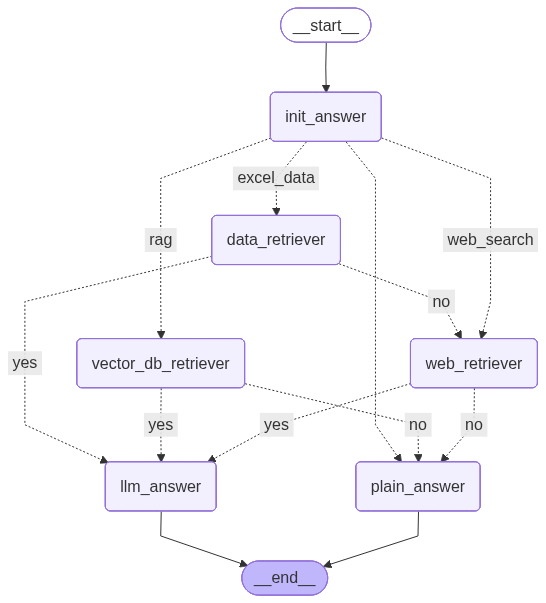

In [23]:
from IPython.display import Image, display

# LangGraph가 제공하는 Mermaid 렌더링 기능을 사용해 그래프 구조를 이미지로 출력합니다.
display(Image(modular_rag.workflow.get_graph().draw_mermaid_png()))

모델 구성을 끝마쳤으면, 한번 사용해 봅시다.

- 예시 질문 (문서 데이터 활용): 인공지능 산업 현황 및 전망에 대해 알려줘
- 예시 질문 (엑셀 데이터 활용): 인공지능 학습용 데이터 구축 현황을 알려줘
- 예시 질문 (인터넷 검색): OpenAI o3-mini 모델을 설명해줘
- 예시 질문 (데이터 무관): 저녁 메뉴 추천해줘

In [24]:
# 위 4가지 경로가 실제로 모두 잘 동작하는지 확인해봅시다.
for sample_question in [
    "인공지능 산업 현황 및 전망에 대해 알려줘",  # 문서 RAG 경로
    "인공지능 학습용 데이터 구축 현황을 알려줘",  # 엑셀 데이터 경로
    "OpenAI o3-mini 모델을 설명해줘",  # 웹 검색 경로
    "저녁 메뉴 추천해줘",  # 일반 답변 경로
]:
    print("=" * 20)
    print("질문:", sample_question)
    print("Assistant:", modular_rag.run(sample_question))

질문: 인공지능 산업 현황 및 전망에 대해 알려줘
---질문 라우팅---
---선택된 경로: rag---
---벡터 DB 검색---
--- is_data_relevant ---
{'relevant': True}
---답변 퀄리티 검증 (Self-RAG)---
{'answer': 'no'}
---주어진 답변은 진실입니다.---
---주어진 답변은 지원적입니다.---
---주어진 답변은 유용합니다.---
Assistant: 인공지능(AI) 산업은 최근 몇 년간 급속히 발전하고 있으며, 다양한 분야에서 혁신을 이끌고 있습니다. 2023년 현재 AI 산업의 현황과 전망에 대해 다음과 같이 정리할 수 있습니다.

### 현황

1. **기술 발전**:
   - **딥러닝과 머신러닝**: 이미지 인식, 자연어 처리(NLP), 자율주행차 등 다양한 분야에서 딥러닝 기술이 활용되고 있습니다.
   - **Generative AI**: GPT-3, DALL-E와 같은 생성적 모델들이 주목받고 있으며, 콘텐츠 생성, 디자인, 음악 작곡 등에서 활용되고 있습니다.
   - **AI 하드웨어**: AI 연산을 위한 전용 하드웨어(예: GPU, TPU)의 발전으로 처리 속도가 크게 향상되었습니다.

2. **산업 적용**:
   - **의료**: 진단 보조, 개인 맞춤형 치료, 약물 개발 등에서 AI가 활용되고 있습니다.
   - **금융**: 리스크 관리, 사기 탐지, 알고리즘 트레이딩 등에서 AI 기술이 사용되고 있습니다.
   - **제조업**: 스마트 팩토리, 품질 관리, 예측 유지보수 등에서 AI가 도입되고 있습니다.
   - **소매 및 마케팅**: 고객 분석, 개인화된 추천 시스템, 재고 관리 등에서 AI가 중요한 역할을 하고 있습니다.

3. **정책 및 규제**:
   - 여러 국가에서 AI의 윤리적 사용과 규제를 위한 정책을 마련하고 있으며, 데이터 보호 및 프라이버시 문제에 대한 논의가 활발히 이루어지고 있습니다.

### 전망

1. **시장 성장**:
   -

In [ ]:
# Note. LLM 특성상 의도하지 않은 방식으로 작동하지 않을 가능성이 있습니다.
while True:
    question = input(
        "질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): "
    )
    if question == "종료":
        break
    answer = modular_rag.run(question)
    print("Assistant:", answer)